# Learning 4 Robotics Expierments

In this lab you will train a robot to run by **watching an expert** — no hand-coded rules, no reward engineering. The technique is called **Behavior Cloning**:

1. An expert policy runs the robot; we record what it sees and does.
2. We treat those recordings as a supervised dataset: **input = observation, label = action**.
3. We train a small neural network (MLP) to predict the expert's actions.
4. We deploy our learned policy and compare it to the expert.

The robot is **HalfCheetah** from MuJoCo — a 2D simulated cheetah that learns to run forward.

---

## ⚙️ Setup — read this before running anything


### ☁️ Running on Google Colab

**1. Switch to a GPU runtime:**
> Runtime → Change runtime type → Hardware accelerator → **T4 GPU** → Save

**2. Run Step 0 first** and wait for `✅ Setup complete`.



## Step 0 — Colab Setup ☁️

> **Local users: skip this cell.**  
> **Colab users: run this cell first** and wait for `✅ Setup complete`.

In [1]:
# ════════════════════════════════════════════════
# COLAB ONLY — local users skip this cell
# ════════════════════════════════════════════════
import subprocess, sys, os

REPO = 'pgss-L4R-IL-public'
if not os.path.isdir(REPO):
    r = subprocess.run(['git', 'clone', 'https://github.com/alokshah04/pgss-L4R-IL-public.git'],
                       capture_output=True, text=True)
    print(r.stdout or r.stderr)
else:
    print('Repo already cloned.')
if not os.getcwd().endswith(REPO):
    os.chdir(REPO)
print('Working directory:', os.getcwd())

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], check=True)
print('\n✅ Setup complete. Continue to Step 1.')

Cloning into 'pgss-L4R-IL-public'...

Working directory: /content/pgss-L4R-IL-public

✅ Setup complete. Continue to Step 1.


In [ ]:
#import subprocess, sys, os
#this is jakes stuff
#print(subprocess.run(['git', 'clone', 'https://github.com/vwxyzjn/cleanrl.git'], capture_output=True, text=True).stdout)
#print(subprocess.run(['cd', 'cleanrl']).stdout)
#print(subprocess.run(['uv', 'pip', 'install', '.']).stdout)

---
## Step 1 — Imports and Expert 💻☁️

*(You may see a `Could not deserialize lr_schedule` warning — harmless. The policy weights load fine.)*

In [2]:
import gymnasium as gym
from stable_baselines3 import SAC
import imageio
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import Video, display

ENV_NAME    = 'HalfCheetah-v5'
EXPERT_PATH = 'experts/HalfCheetah-v5'

expert = SAC.load(EXPERT_PATH)
print('Expert policy loaded.')

env = gym.make(ENV_NAME)
print(f'Observation space: {env.observation_space}')   # what the robot sees
print(f'Action space:      {env.action_space}')        # what the robot does
env.close()

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/save_util.py:165: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  deserialized_object = cl

Expert policy loaded.
Observation space: Box(-inf, inf, (17,), float64)
Action space:      Box(-1.0, 1.0, (6,), float32)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Step 1a — Video recorder 💻 (local only)

> **Colab users: skip Steps 1a and 1b.** Video rendering requires a display, which Colab does not have.

We use gymnasium's built-in `rgb_array` renderer to record frames.

In [ ]:
# ════════════════════════════════════════════════
# LOCAL ONLY — Colab users skip this cell
# ════════════════════════════════════════════════
def record_policy(step_fn, env_name, path, max_steps=300, seed=1, fps=30):
    """Run step_fn(obs) -> action and save an MP4 using gymnasium's rgb_array renderer."""
    env = gym.make(env_name, render_mode='rgb_array')
    obs, _ = env.reset(seed=seed)
    frames, total_reward = [], 0.0
    for _ in range(max_steps):
        action = step_fn(obs)
        obs, reward, done, truncated, _ = env.step(action)
        total_reward += reward
        frames.append(env.render())
        if done or truncated:
            break
    env.close()
    imageio.mimsave(path, frames, fps=fps)
    print(f'Saved {path}  |  reward: {total_reward:.1f}  |  frames: {len(frames)}')
    return total_reward

print('record_policy defined.')

### Step 1b — Watch the expert run 💻 (local only)

> **Colab users: skip this cell.**

In [ ]:
# ════════════════════════════════════════════════
# LOCAL ONLY — Colab users skip this cell
# ════════════════════════════════════════════════
def expert_step(obs):
    action, _ = expert.predict(obs, deterministic=True)
    return action

record_policy(expert_step, ENV_NAME, 'expert_demo.mp4')
display(Video('expert_demo.mp4', embed=True, width=600))

---
## Step 2 — Collect Demonstrations 💻☁️

We roll out the expert many times and store every *(observation, action)* pair it produces.

Each **trajectory** is a dictionary with three lists:
```
{
  'obs'     : [o_0, o_1, ..., o_T],   # what the robot saw at each step
  'acts'    : [a_0, a_1, ..., a_T],   # what the expert did at each step
  'rewards' : [r_0, r_1, ..., r_T],   # reward received at each step
}
```

We collect `NUM_TRAJ` trajectories in total, then split them **70 / 10** into a **training set** and a **validation set**. The model only sees the training set during gradient updates; the validation set is used to check that it generalises to unseen data.

In [3]:
NUM_TRAJ      = 80
MAX_TIMESTEPS = 300
VAL_TRAJ      = 10   # held-out trajectories for validation

print(f'Collecting {NUM_TRAJ} expert trajectories...')

env = gym.make(ENV_NAME)
policy = SAC.load(EXPERT_PATH)
env.reset(seed=42)

all_trajectories = []
for ep in range(NUM_TRAJ):
    obs, _ = env.reset()
    traj = {'obs': [], 'acts': [], 'rewards': []}
    for _ in range(MAX_TIMESTEPS):
        traj['obs'].append(obs.copy())
        action, _ = policy.predict(obs, deterministic=True)
        traj['acts'].append(action)
        obs, reward, done, truncated, _ = env.step(action)
        traj['rewards'].append(reward)
        if done or truncated:
            break
    all_trajectories.append(traj)
env.close()

# Split into train and val
train_trajs = all_trajectories[:NUM_TRAJ - VAL_TRAJ]
val_trajs   = all_trajectories[NUM_TRAJ - VAL_TRAJ:]

print(f'Train trajectories: {len(train_trajs)}')
print(f'Val   trajectories: {len(val_trajs)}')

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/save_util.py:165: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  deserialized_object = cloudpickle.loads(base64_object)
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/save_util.py:167: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code() argument 13 must be str, not int
  warnings.warn(


Train trajectories: 70
Val   trajectories: 10


In [4]:
# Inspect one trajectory
traj0 = train_trajs[0]
obs0, acts0 = np.array(traj0['obs']), np.array(traj0['acts'])
print(f'Trajectory length: {len(traj0["obs"])} steps')
print(f'Observation shape: {obs0.shape}  (T x obs_dim)')
print(f'Action shape:      {acts0.shape}  (T x act_dim)')
print(f'Total reward:      {sum(traj0["rewards"]):.1f}')
print('\nFirst observation (what the robot sees at t=0):')
print(obs0[0])
print('\nFirst expert action (what the expert does at t=0):')
print(acts0[0])

Trajectory length: 300 steps
Observation shape: (300, 17)  (T x obs_dim)
Action shape:      (300, 6)  (T x act_dim)
Total reward:      2966.4

First observation (what the robot sees at t=0):
[ 0.02633288  0.05161755 -0.02909481  0.0941396   0.07862422  0.0556767
 -0.06107226 -0.0066558   0.03654441  0.04127326  0.0430821   0.21416476
 -0.0406415  -0.05122427 -0.08137727  0.06159794  0.11289723]

First expert action (what the expert does at t=0):
[ 0.9471673  -0.95543474  0.82663107 -0.9525958  -0.9551406  -0.9437293 ]


---
## Step 3 — Build a Supervised Learning Dataset 💻☁️

We flatten all trajectories into a flat list of *(observation, action)* pairs — exactly like any supervised learning problem:
- **Input X** = observation vector (17 numbers: joint angles & velocities)
- **Label Y** = action vector (6 numbers: one torque per joint)

We do this separately for the train and validation splits, then wrap each in a PyTorch `DataLoader` that handles batching and shuffling.

In [5]:
class TrajDataset(Dataset):
    """
    Converts a list of trajectories into a PyTorch Dataset of (obs, action) pairs.
    Each sample is one timestep: the observation the robot saw and the action the expert took.
    """
    def __init__(self, trajectories):
        obs_list, act_list = [], []
        for traj in trajectories:
            obs_list.extend(traj['obs'])
            act_list.extend(traj['acts'])
        self.inputs = torch.tensor(np.array(obs_list), dtype=torch.float32)
        self.labels = torch.tensor(np.array(act_list), dtype=torch.float32)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.labels[idx]


BATCH_SIZE = 256

train_dataset = TrajDataset(train_trajs)
val_dataset   = TrajDataset(val_trajs)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f'Train samples: {len(train_dataset)}')
print(f'Val   samples: {len(val_dataset)}')

obs_batch, act_batch = next(iter(train_loader))
print(f'\nOne batch: observations {obs_batch.shape}, actions {act_batch.shape}')

OBS_DIM = obs_batch.shape[1]
ACT_DIM = act_batch.shape[1]
print(f'obs_dim = {OBS_DIM},  act_dim = {ACT_DIM}')

Train samples: 21000
Val   samples: 3000

One batch: observations torch.Size([256, 17]), actions torch.Size([256, 6])
obs_dim = 17,  act_dim = 6


---
## Step 4 — Define the Policy Network 💻☁️

Our learned policy is a **Multi-Layer Perceptron (MLP)**. It takes an observation as input and outputs a predicted action.

Each hidden layer has three components:
- **`Linear`** — a learned matrix multiply (the weights we train)
- **`LayerNorm`** — normalises activations so the policy generalises better to observations it didn't see during training
- **`GELU`** — a smooth non-linearity that lets the network represent complex functions

```
observation (17) -> [Linear -> LayerNorm -> GELU] x 3 -> action (6)
```

The output layer has **no activation** — actions are continuous real numbers with no fixed range (before environment clipping).

**Your turn — try changing `HIDDEN_SIZE` (e.g. 64, 128, 512).**

In [6]:
class MLP(nn.Module):
    """
    A 3-hidden-layer MLP that maps observations to actions.
    This is our learned policy: given what the robot sees, predict what to do.
    """
    def __init__(self, obs_dim, act_dim, hidden_size=256):
        super().__init__()
        self.net = nn.Sequential(
            #this is the 9 layers
            #3 for each layer
            nn.Linear(obs_dim, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.GELU(),

            nn.Linear(hidden_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.GELU(),

            nn.Linear(hidden_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.GELU(),

            #last one
            nn.Linear(hidden_size, act_dim),
        )

    def forward(self, x):
        return self.net(x)


HIDDEN_SIZE = 256
model = MLP(obs_dim=OBS_DIM, act_dim=ACT_DIM, hidden_size=HIDDEN_SIZE)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

MLP(
  (net): Sequential(
    (0): Linear(in_features=17, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (8): GELU(approximate='none')
    (9): Linear(in_features=256, out_features=6, bias=True)
  )
)

Total parameters: 139,270


---
## Step 5 — Train the Policy 💻☁️

We train with **Mean Squared Error** loss — for each observation in the batch, the model predicts an action and we penalise it for how far that prediction is from what the expert actually did:

$$\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} \| \hat{a}_i - a_i^{\text{expert}} \|^2$$

We use the **AdamW** optimiser with a **cosine learning-rate schedule** that gradually reduces the learning rate over training.

After each epoch we also compute the **validation loss** on the held-out trajectories — this tells us whether the model is generalising or just memorising the training data.

**On Colab with T4 GPU:** ~2 minutes &nbsp;|&nbsp; **On a laptop CPU:** ~10 minutes

**Your turn — try changing `EPOCHS` or `LR`.**

In [7]:
EPOCHS = 500   #i feel like this is a lot
LR     = 1e-3   #benchmark, found online
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Training on: {DEVICE}')
#this takes 10 mins to run

model = model.to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LR)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.MSELoss()

train_losses, val_losses = [], []

for epoch in tqdm(range(EPOCHS), desc='Training'):
    # ── training pass ────────────────────────────────────────
    model.train()
    total_train = 0.0
    for obs, acts in train_loader:
      #this is the big training loop
        obs, acts = obs.to(DEVICE), acts.to(DEVICE)
        preds = model(obs)
        loss  = criterion(preds, acts)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train += loss.item() * obs.size(0)
    scheduler.step()
    train_losses.append(total_train / len(train_dataset))

    # ── validation pass (no gradients) ───────────────────────
    model.eval()
    total_val = 0.0
    with torch.no_grad():
        for obs, acts in val_loader:
            obs, acts = obs.to(DEVICE), acts.to(DEVICE)
            preds = model(obs)
            total_val += criterion(preds, acts).item() * obs.size(0)
    val_losses.append(total_val / len(val_dataset))

difference = np.array(train_losses) - np.array(val_losses)


print(f'Final train loss: {train_losses[-1]:.6f}')
print(f'Final val   loss: {val_losses[-1]:.6f}')
print(f'Difference between train and val: {difference[-1]:.6f}')
#added this to see how far off we are


Training on: cuda


Training: 100%|██████████| 500/500 [03:09<00:00,  2.64it/s]

Final train loss: 0.000433
Final val   loss: 0.004644
Difference between train and val: -0.004211


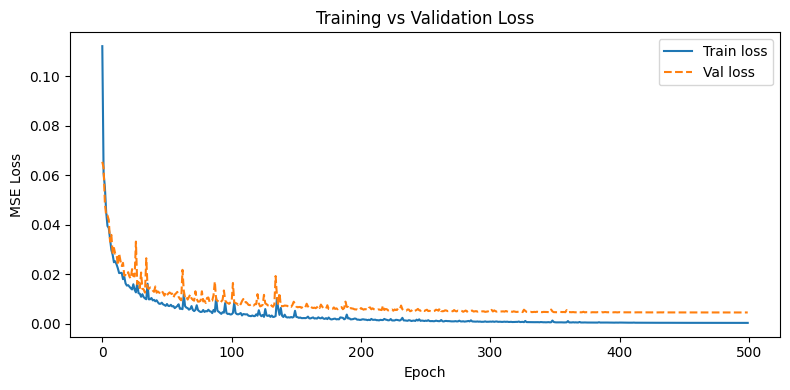

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses,   label='Val loss', linestyle='--')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.tight_layout(); plt.savefig('training_loss.png', dpi=120); plt.show()

---
## Step 6 — Evaluate on Test Rollouts 💻☁️

A low validation loss means the model predicts expert actions accurately on unseen data — but that's not the same as the robot actually being able to run. When deployed, small prediction errors **compound** over time: the robot ends up in states it never saw during training, which leads to worse predictions, which leads to worse states, and so on.

The true test is to **roll the learned policy out in the environment** and measure the total reward it earns. We compare this against the expert over `NUM_EVAL_TRAJ` fresh episodes (the **test set**).

In [9]:
NUM_EVAL_TRAJ = 10
model = model.cpu().eval()

#hi jake can u see thiss

expert_returns  = []
learned_returns = []

rng = np.random.default_rng(0)
for _ in tqdm(range(NUM_EVAL_TRAJ), desc='Evaluating'):
    seed = int(rng.integers(0, 2**31))

    # ── expert rollout ───────────────────────────────────────
    env = gym.make(ENV_NAME)
    obs, _ = env.reset(seed=seed)
    ep_reward = 0.0
    for _ in range(MAX_TIMESTEPS):
        action, _ = policy.predict(obs, deterministic=True)
        obs, reward, done, truncated, _ = env.step(action)
        ep_reward += reward
        if done or truncated: break
    env.close()
    expert_returns.append(ep_reward)

    # ── learned policy rollout ───────────────────────────────
    env = gym.make(ENV_NAME)
    obs, _ = env.reset(seed=seed)
    ep_reward = 0.0
    with torch.no_grad():
        for _ in range(MAX_TIMESTEPS):
            obs_t  = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
            action = model(obs_t).squeeze(0).numpy()
            obs, reward, done, truncated, _ = env.step(action)
            ep_reward += reward
            if done or truncated: break
    env.close()
    learned_returns.append(ep_reward)

expert_returns  = np.array(expert_returns)
learned_returns = np.array(learned_returns)

print(f'Expert  avg return: {expert_returns.mean():.1f} +/- {expert_returns.std():.1f}')
print(f'Learned avg return: {learned_returns.mean():.1f} +/- {learned_returns.std():.1f}')
reward_gap = (expert_returns.mean() - learned_returns.mean()) / abs(expert_returns.mean())
print(f'Normalised reward gap: {reward_gap:.1%}')

Evaluating: 100%|██████████| 10/10 [00:04<00:00,  2.10it/s]

Expert  avg return: 3030.9 +/- 45.4
Learned avg return: 2025.6 +/- 1332.2
Normalised reward gap: 33.2%


/tmp/ipykernel_462/3202646983.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([expert_returns, learned_returns],
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


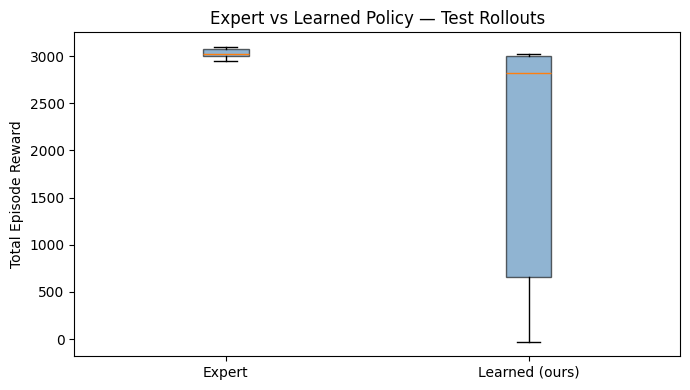

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([expert_returns, learned_returns],
           labels=['Expert', 'Learned (ours)'], patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_ylabel('Total Episode Reward'); ax.set_title('Expert vs Learned Policy — Test Rollouts')
plt.tight_layout(); plt.savefig('eval_rewards.png', dpi=120); plt.show()

---
# Part 2 — Training an RL Policy with PPO (CleanRL)

The custom PPO implementation that used to live in this section (the "Bridge" class,
`RolloutBuffer`, hand-written `ppo_update`) had bugs and has been removed. In its place,
this notebook now uses **[CleanRL](https://docs.cleanrl.dev/rl-algorithms/ppo/)'s
reference `ppo_continuous_action.py`** — a widely-used, well-tested PPO implementation —
adapted to run inside a notebook (no `argparse`, no command-line script).

**One deliberate design choice:** rather than trying to bridge the IL model (`model`,
a 256-unit GELU/LayerNorm MLP) into CleanRL's actor-critic (a 64-unit Tanh MLP with a
different architecture), this PPO agent trains **from scratch**, using CleanRL's own
network. That mismatch-bridging is exactly what the old broken code was trying (and
failing) to do. Training from scratch is slower to reach the IL policy's starting
quality, but it's simple and it works. At the end, we compare all three: **Expert
(SAC)**, **IL (behavior cloning)**, and **PPO (RL from scratch)**.

Same environment throughout: `HalfCheetah-v5`.

> ⚠️ If you're on Colab, make sure you're still on a **T4 GPU** runtime (Runtime → Change
> runtime type). With the default settings below (500k steps, 4 parallel envs) expect
> roughly 10-20 min on GPU.


In [39]:
# ── PPO (CleanRL) imports ─────────────────────────────────────────────────────
import random
import time
from types import SimpleNamespace
from collections import deque

from torch.distributions.normal import Normal

try:
    from torch.utils.tensorboard import SummaryWriter
    TENSORBOARD_AVAILABLE = True
except Exception:
    TENSORBOARD_AVAILABLE = False
    print('TensorBoard not available — training will still run, just without logging to runs/.')

print('Ready for RL training.')


Ready for RL training.


### Step A — PPO Hyperparameters

Same knobs as CleanRL's script, just set directly as a `SimpleNamespace` instead of
parsed from the command line (there's no command line in a notebook). `total_timesteps`
is trimmed down from CleanRL's usual 1M default to keep runtime reasonable — bump it up
if you want a more polished policy and don't mind a longer run.


In [40]:
args = SimpleNamespace(
    exp_name        = 'ppo_halfcheetah',
    seed            = 42,
    torch_deterministic = True,
    cuda            = True,
    track           = False,          # set True + `pip install wandb` for W&B logging
    wandb_project_name = 'cleanRL',
    wandb_entity    = None,
    capture_video   = False,

    # ── Environment ──────────────────────────────────────────────────────────
    env_id          = ENV_NAME,       # 'HalfCheetah-v5', from Step 1

    # ── Rollout collection ───────────────────────────────────────────────────
    total_timesteps = 500_000,        # CleanRL default is 1_000_000; trimmed for speed
    num_envs        = 4,
    num_steps       = 2048,

    # ── PPO update ───────────────────────────────────────────────────────────
    learning_rate   = 3e-4,
    anneal_lr       = True,
    gamma           = 0.99,
    gae_lambda      = 0.95,
    num_minibatches = 32,
    update_epochs   = 10,
    norm_adv        = True,
    clip_coef       = 0.2,
    clip_vloss      = True,
    ent_coef        = 0.0,
    vf_coef         = 0.5,
    max_grad_norm   = 0.5,
    target_kl       = None,
)
args.batch_size = int(args.num_envs * args.num_steps)
args.minibatch_size = int(args.batch_size // args.num_minibatches)
num_updates = args.total_timesteps // args.batch_size

print(f'Batch size: {args.batch_size:,}   Minibatch size: {args.minibatch_size}')
print(f'Total updates: {num_updates}   ({args.total_timesteps/1e6:.2f}M env steps)')


Batch size: 8,192   Minibatch size: 256
Total updates: 61   (0.50M env steps)


### Step B — Vectorized Environments and the Actor-Critic

`make_env` builds one wrapped HalfCheetah environment (observation normalization,
reward clipping, episode-stats tracking, etc. — all standard CleanRL preprocessing).
`Agent` is CleanRL's actor-critic: two small separate MLPs (actor and critic), each
with orthogonal weight initialization, plus a learned log-std for exploration noise.
This is trained **from scratch**, unlike the old Bridge class.


In [41]:
def make_env(env_id, seed, idx, capture_video, run_name, gamma):
    def thunk():
        if capture_video and idx == 0:
            env = gym.make(env_id, render_mode='rgb_array')
        else:
            env = gym.make(env_id)
        env = gym.wrappers.FlattenObservation(env)
        env = gym.wrappers.RecordEpisodeStatistics(env)
        if capture_video and idx == 0:
            env = gym.wrappers.RecordVideo(env, f'videos/{run_name}')
        env = gym.wrappers.ClipAction(env)
        env = gym.wrappers.NormalizeReward(env, gamma=gamma)
        env = gym.wrappers.TransformReward(env, lambda reward: np.clip(reward, -10, 10))
        env.action_space.seed(seed)
        return env
    return thunk


def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer


class Agent(nn.Module):
    def __init__(self, envs):
        super().__init__()
        self.critic = nn.Sequential(
            layer_init(nn.Linear(np.array(envs.single_observation_space.shape).prod(), 64)),
            nn.Tanh(),
            layer_init(nn.Linear(64, 64)),
            nn.Tanh(),
            layer_init(nn.Linear(64, 1), std=1.0),
        )
        self.actor_mean = nn.Sequential(
            nn.Linear(np.array(envs.single_observation_space.shape).prod(), 256), nn.LayerNorm(256), nn.GELU(),
            nn.Linear(256, 256), nn.LayerNorm(256), nn.GELU(),
            nn.Linear(256, 256), nn.LayerNorm(256), nn.GELU(),
            nn.Linear(256, np.prod(envs.single_action_space.shape)),
        )
        self.actor_logstd = nn.Parameter(torch.ones(1, np.prod(envs.single_action_space.shape)) * -0.5)

    def get_value(self, x):
        return self.critic(x)

    def get_action_and_value(self, x, action=None):
        action_mean = self.actor_mean(x)
        action_logstd = self.actor_logstd.expand_as(action_mean)
        action_std = torch.exp(action_logstd)
        probs = Normal(action_mean, action_std)
        if action is None:
            action = probs.sample()
        return action, probs.log_prob(action).sum(1), probs.entropy().sum(1), self.critic(x)


print('make_env, layer_init, Agent defined.')

make_env, layer_init, Agent defined.


### Step C — Train! 🏋️

This is CleanRL's training loop almost unchanged, with two adjustments for the notebook:

1. No `argparse` / `if __name__ == "__main__":` — it just runs in this cell.
2. The episode-logging check is updated from `infos["final_info"]` to
   `infos["episode"]` / `infos["_episode"]`, since Gymnasium 1.x changed how vectorized
   environments report per-episode stats (the old key doesn't exist any more, which was
   silently swallowing every episode-return print/log).


In [ ]:
run_name = f'{args.env_id}__{args.exp_name}__{args.seed}__{int(time.time())}'

if args.track:
    import wandb
    wandb.init(
        project=args.wandb_project_name,
        entity=args.wandb_entity,
        sync_tensorboard=True,
        config=vars(args),
        name=run_name,
        monitor_gym=True,
        save_code=True,
    )

if TENSORBOARD_AVAILABLE:
    writer = SummaryWriter(f'runs/{run_name}')
    writer.add_text(
        'hyperparameters',
        '|param|value|\n|-|-|\n%s' % ('\n'.join([f'|{k}|{v}|' for k, v in vars(args).items()])),
    )
else:
    class _NoOpWriter:
        def add_scalar(self, *a, **k): pass
        def add_text(self, *a, **k): pass
        def close(self): pass
    writer = _NoOpWriter()

# TRY NOT TO MODIFY: seeding
random.seed(args.seed)
np.random.seed(args.seed)
torch.manual_seed(args.seed)
torch.backends.cudnn.deterministic = args.torch_deterministic

device = torch.device('cuda' if torch.cuda.is_available() and args.cuda else 'cpu')
print(f'Training on: {device}')

# env setup
#envs = gym.vector.SyncVectorEnv(
  #  [make_env(args.env_id, args.seed + i, i, args.capture_video, run_name, args.gamma) for i in range(args.num_envs)]
#)
#assert isinstance(envs.single_action_space, gym.spaces.Box), 'only continuous action space is supported'


envs = gym.vector.SyncVectorEnv(
    [make_env(args.env_id, args.seed + i, i, args.capture_video, run_name, args.gamma) for i in range(args.num_envs)]
)

assert isinstance(envs.single_action_space, gym.spaces.Box), 'only continuous action space is supported'

agent = Agent(envs).to(device)
agent.actor_mean.load_state_dict(model.net.state_dict())
print('Loaded IL weights into PPO actor.')
optimizer = optim.Adam(agent.parameters(), lr=args.learning_rate, eps=1e-5)



# ALGO Logic: Storage setup
obs      = torch.zeros((args.num_steps, args.num_envs) + envs.single_observation_space.shape).to(device)
actions  = torch.zeros((args.num_steps, args.num_envs) + envs.single_action_space.shape).to(device)
logprobs = torch.zeros((args.num_steps, args.num_envs)).to(device)
rewards  = torch.zeros((args.num_steps, args.num_envs)).to(device)
dones    = torch.zeros((args.num_steps, args.num_envs)).to(device)
values   = torch.zeros((args.num_steps, args.num_envs)).to(device)

# TRY NOT TO MODIFY: start the game
global_step = 0
start_time = time.time()
next_obs, _ = envs.reset(seed=args.seed)
next_obs = torch.Tensor(next_obs).to(device)
next_done = torch.zeros(args.num_envs).to(device)

episodic_returns_rl = []          # for plotting later
recent_returns = deque(maxlen=20) # for the progress bar

pbar = tqdm(range(1, num_updates + 1), desc='PPO training')
for update in pbar:
    # Annealing the rate if instructed to do so.
    if args.anneal_lr:
        frac = 1.0 - (update - 1.0) / num_updates
        lrnow = frac * args.learning_rate
        optimizer.param_groups[0]['lr'] = lrnow

    for step in range(0, args.num_steps):
        global_step += 1 * args.num_envs
        obs[step] = next_obs
        dones[step] = next_done

        # ALGO LOGIC: action logic
        with torch.no_grad():
            action, logprob, _, value = agent.get_action_and_value(next_obs)
            values[step] = value.flatten()
        actions[step] = action
        logprobs[step] = logprob

        # TRY NOT TO MODIFY: execute the game and log data.
        next_obs, reward, terminated, truncated, infos = envs.step(action.cpu().numpy())
        done = np.logical_or(terminated, truncated)
        rewards[step] = torch.tensor(reward).to(device).view(-1)
        next_obs, next_done = torch.Tensor(next_obs).to(device), torch.Tensor(done).to(device)

        # Gymnasium 1.x reports finished episodes via "episode"/"_episode",
        # not the old "final_info" key.
        if 'episode' in infos:
            for i, finished in enumerate(infos['_episode']):
                if finished:
                    ep_ret = float(infos['episode']['r'][i])
                    ep_len = int(infos['episode']['l'][i])
                    episodic_returns_rl.append(ep_ret)
                    recent_returns.append(ep_ret)
                    writer.add_scalar('charts/episodic_return', ep_ret, global_step)
                    writer.add_scalar('charts/episodic_length', ep_len, global_step)

    if recent_returns:
        pbar.set_postfix({'steps': f'{global_step/1e6:.2f}M', 'ret': f'{np.mean(recent_returns):.0f}'})

    # bootstrap value if not done
    with torch.no_grad():
        next_value = agent.get_value(next_obs).reshape(1, -1)
        advantages = torch.zeros_like(rewards).to(device)
        lastgaelam = 0
        for t in reversed(range(args.num_steps)):
            if t == args.num_steps - 1:
                nextnonterminal = 1.0 - next_done
                nextvalues = next_value
            else:
                nextnonterminal = 1.0 - dones[t + 1]
                nextvalues = values[t + 1]
            delta = rewards[t] + args.gamma * nextvalues * nextnonterminal - values[t]
            advantages[t] = lastgaelam = delta + args.gamma * args.gae_lambda * nextnonterminal * lastgaelam
        returns = advantages + values

    # flatten the batch
    b_obs = obs.reshape((-1,) + envs.single_observation_space.shape)
    b_logprobs = logprobs.reshape(-1)
    b_actions = actions.reshape((-1,) + envs.single_action_space.shape)
    b_advantages = advantages.reshape(-1)
    b_returns = returns.reshape(-1)
    b_values = values.reshape(-1)

    # Optimizing the policy and value network
    b_inds = np.arange(args.batch_size)
    clipfracs = []
    for epoch in range(args.update_epochs):
        np.random.shuffle(b_inds)
        for start in range(0, args.batch_size, args.minibatch_size):
            end = start + args.minibatch_size
            mb_inds = b_inds[start:end]

            _, newlogprob, entropy, newvalue = agent.get_action_and_value(b_obs[mb_inds], b_actions[mb_inds])
            logratio = newlogprob - b_logprobs[mb_inds]
            ratio = logratio.exp()

            with torch.no_grad():
                old_approx_kl = (-logratio).mean()
                approx_kl = ((ratio - 1) - logratio).mean()
                clipfracs += [((ratio - 1.0).abs() > args.clip_coef).float().mean().item()]

            mb_advantages = b_advantages[mb_inds]
            if args.norm_adv:
                mb_advantages = (mb_advantages - mb_advantages.mean()) / (mb_advantages.std() + 1e-8)

            # Policy loss
            pg_loss1 = -mb_advantages * ratio
            pg_loss2 = -mb_advantages * torch.clamp(ratio, 1 - args.clip_coef, 1 + args.clip_coef)
            pg_loss = torch.max(pg_loss1, pg_loss2).mean()

            # Value loss
            newvalue = newvalue.view(-1)
            if args.clip_vloss:
                v_loss_unclipped = (newvalue - b_returns[mb_inds]) ** 2
                v_clipped = b_values[mb_inds] + torch.clamp(
                    newvalue - b_values[mb_inds], -args.clip_coef, args.clip_coef,
                )
                v_loss_clipped = (v_clipped - b_returns[mb_inds]) ** 2
                v_loss_max = torch.max(v_loss_unclipped, v_loss_clipped)
                v_loss = 0.5 * v_loss_max.mean()
            else:
                v_loss = 0.5 * ((newvalue - b_returns[mb_inds]) ** 2).mean()

            entropy_loss = entropy.mean()
            loss = pg_loss - args.ent_coef * entropy_loss + v_loss * args.vf_coef

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(), args.max_grad_norm)
            optimizer.step()

        if args.target_kl is not None and approx_kl > args.target_kl:
            break

    y_pred, y_true = b_values.cpu().numpy(), b_returns.cpu().numpy()
    var_y = np.var(y_true)
    explained_var = np.nan if var_y == 0 else 1 - np.var(y_true - y_pred) / var_y

    writer.add_scalar('charts/learning_rate', optimizer.param_groups[0]['lr'], global_step)
    writer.add_scalar('losses/value_loss', v_loss.item(), global_step)
    writer.add_scalar('losses/policy_loss', pg_loss.item(), global_step)
    writer.add_scalar('losses/entropy', entropy_loss.item(), global_step)
    writer.add_scalar('losses/old_approx_kl', old_approx_kl.item(), global_step)
    writer.add_scalar('losses/approx_kl', approx_kl.item(), global_step)
    writer.add_scalar('losses/clipfrac', np.mean(clipfracs), global_step)
    writer.add_scalar('losses/explained_variance', explained_var, global_step)
    writer.add_scalar('charts/SPS', int(global_step / (time.time() - start_time)), global_step)

envs.close()
writer.close()

torch.save(agent.state_dict(), 'ppo_halfcheetah.pt')
print(f'\nTraining complete in {(time.time() - start_time)/60:.1f} min. Saved ppo_halfcheetah.pt')

Training on: cuda
Loaded IL weights into PPO actor.


PPO training:  21%|██▏       | 13/61 [01:44<06:15,  7.82s/it, steps=0.11M, ret=849]

### Step D — Evaluate and Compare: Expert vs IL vs PPO

Deterministic rollouts (using the actor's mean action, no exploration noise) for the
trained PPO agent, evaluated the same way the IL model was evaluated back in Step 6 —
same `NUM_EVAL_TRAJ`, same `MAX_TIMESTEPS`, so the three sets of returns are directly
comparable.


In [32]:
def evaluate_ppo_agent(agent, env_id, num_episodes=10, max_steps=300, seed=999, device='cpu'):
    """Deterministic (mean-action) rollouts of the trained PPO agent."""
    agent.eval()
    returns = []
    for ep in range(num_episodes):
        env = gym.make(env_id)
        obs, _ = env.reset(seed=seed + ep)
        ep_ret = 0.0
        with torch.no_grad():
            for _ in range(max_steps):
                obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
                action = agent.actor_mean(obs_t).squeeze(0).cpu().numpy()
                obs, reward, terminated, truncated, _ = env.step(action)
                ep_ret += reward
                if terminated or truncated:
                    break
        env.close()
        returns.append(ep_ret)
    agent.train()
    return np.array(returns)


ppo_returns = evaluate_ppo_agent(
    agent, ENV_NAME, num_episodes=NUM_EVAL_TRAJ, max_steps=MAX_TIMESTEPS, device=device,
)

print(f'Expert avg return: {expert_returns.mean():.1f} +/- {expert_returns.std():.1f}')
print(f'IL     avg return: {learned_returns.mean():.1f} +/- {learned_returns.std():.1f}')
print(f'PPO    avg return: {ppo_returns.mean():.1f} +/- {ppo_returns.std():.1f}')


Expert avg return: 3030.9 +/- 45.4
IL     avg return: 2025.6 +/- 1332.2
PPO    avg return: -301.6 +/- 27.9


/tmp/ipykernel_462/2191837018.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


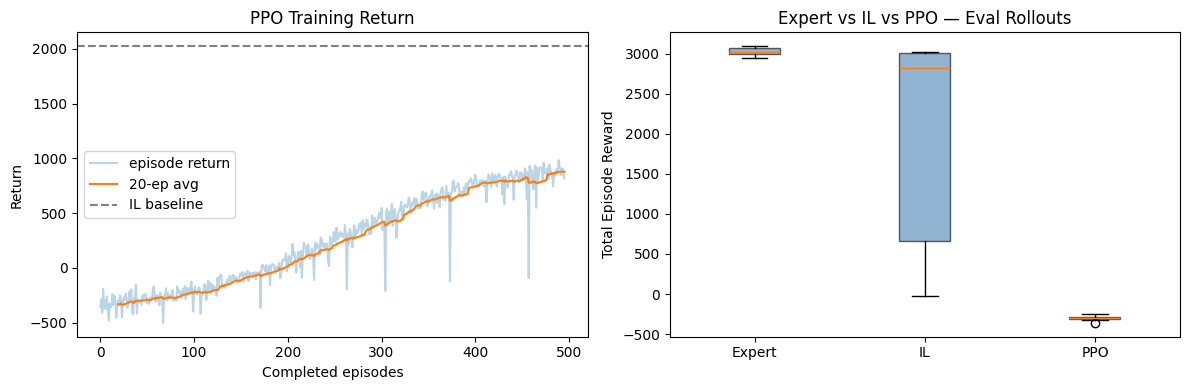

IL  eval return:  2025.6 +/- 1332.2
PPO eval return:  -301.6 +/- 27.9
Delta (PPO - IL): -2327.2


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(episodic_returns_rl, alpha=0.3, label='episode return')
W = 20
if len(episodic_returns_rl) >= W:
    smooth = np.convolve(episodic_returns_rl, np.ones(W) / W, mode='valid')
    axes[0].plot(range(W - 1, len(episodic_returns_rl)), smooth, label=f'{W}-ep avg')
axes[0].axhline(learned_returns.mean(), color='gray', linestyle='--', label='IL baseline')
axes[0].set_xlabel('Completed episodes'); axes[0].set_ylabel('Return')
axes[0].set_title('PPO Training Return'); axes[0].legend()

axes[1].boxplot(
    [expert_returns, learned_returns, ppo_returns],
    labels=['Expert', 'IL', 'PPO'], patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
)
axes[1].set_ylabel('Total Episode Reward')
axes[1].set_title('Expert vs IL vs PPO — Eval Rollouts')

plt.tight_layout()
plt.savefig('il_vs_ppo_comparison.png', dpi=120)
plt.show()

print(f'IL  eval return:  {learned_returns.mean():.1f} +/- {learned_returns.std():.1f}')
print(f'PPO eval return:  {ppo_returns.mean():.1f} +/- {ppo_returns.std():.1f}')
print(f'Delta (PPO - IL): {ppo_returns.mean() - learned_returns.mean():+.1f}')
